In [2]:
from gurobipy import Model, GRB, quicksum
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from Heuristica import heuristica_agendamento
import matplotlib.patches as mpatches

In [22]:
# ------------------ DADOS DE ENTRADA ------------------ #

# Número de Núcleos 
n_nucleos = 14

# ------------------ Núcleos selecionados do modelo exato ------------------ #
# M = [1..14] 
M = list(range(1, n_nucleos + 1))

# Núcleo interno i -> (14 Núcleos existentes atualmente em São Paulo)

info_nucleo = {
    1:  {"id_real": 88, "distrito": "BRAS"},          # Casa Restaura-Me
    2:  {"id_real": 49, "distrito": "BELEM"},         # Centro Comunitário São Martinho de Lima
    3:  {"id_real": 31, "distrito": "GUAIANASES"},    # Núcleo de Convivência São Rafael
    4:  {"id_real": 54, "distrito": "SAO MATEUS"},    # Núcleo Pop São Mateus – Pipas
    5:  {"id_real": 60, "distrito": "BELA VISTA"},    # Núcleo Inforedes – Bela Vista
    6:  {"id_real": 60, "distrito": "BELA VISTA"},    # Núcleo de Convivência Dom Orione
    7:  {"id_real": 72, "distrito": "BOM RETIRO"},    # Casa de Convivência Porto Seguro
    8:  {"id_real": 72, "distrito": "BOM RETIRO"},    # Núcleo Prates
    9:  {"id_real": 77, "distrito": "BARRA FUNDA"},   # Núcleo Boracea
    10: {"id_real": 94, "distrito": "SE"},            # Núcleo Chá do Padre
    11: {"id_real": 30, "distrito": "REPUBLICA"},     # Núcleo Boticário
    12: {"id_real": 94, "distrito": "SE"},            # Núcleo Rodrigo Silva
    13: {"id_real": 51, "distrito": "SANTANA"},       # Núcleo Santana
    14: {"id_real": 37, "distrito": "PINHEIROS"},     # Núcleo de Convivência Pinheiros
}
# dicionário auxiliar só com o distrito de cada núcleo interno
distrito_nucleo = {i: info["distrito"] for i, info in info_nucleo.items()}

# ------------------ Distritos e demanda ------------------ #

# Matriz de distâncias dos distritos (mesmo arquivo do modelo de localização)
matriz_df = pd.read_csv("matriz_distancias_distritos.csv", index_col=0)

# Padronizar nomes da matriz (maiúsculas, sem acento)
matriz_df.index = (
    matriz_df.index.str.upper()
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("ascii")
)

# Lista de distritos na ordem da matriz
distritos_sp = list(matriz_df.index)

# Ler CSV da Demanda PopRua
demanda_df = pd.read_csv("demanda_por_distrito.csv", sep=";")

# Padronizar nomes dos distritos no CSV da Demanda PopRua
demanda_df["distrito"] = (
    demanda_df["distrito"].str.upper()
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("ascii")
)

demanda_df = demanda_df.set_index("distrito")

# Padronização dos nomes do distrito São Miguel Paulista -> São Miguel
demanda_df = demanda_df.rename(index={"SAO MIGUEL PAULISTA": "SAO MIGUEL"})

# Aferição se todos os distritos da matriz têm demanda
missing = set(distritos_sp) - set(demanda_df.index)
if missing:
    raise ValueError(f"Distritos sem demanda no CSV: {missing}")

# Reordenamento da demanda na mesma ordem de distritos_sp
demanda_df = demanda_df.loc[distritos_sp]

# ------------------ Total de pessoas poprua ------------------ #

n_poprua = int(demanda_df["demanda"].sum())

# Conjunto de pessoas (tarefas)
J = list(range(1, n_poprua + 1))

# ------------------ Dicionário poprua -> distrito ------------------ #
# distribuição das pessoas em situação de rua pelos distritos, proporcionalmente à demanda_df

distrito_por_pessoa = {}
j_atual = 1
demanda_total = demanda_df["demanda"].sum()

for distrito, row in demanda_df.iterrows():
    demanda_distrito = int(row["demanda"])
    if demanda_distrito <= 0:
        continue
    frac = demanda_distrito / demanda_total
    qtd_pessoas = int(round(frac * n_poprua))
    for _ in range(qtd_pessoas):
        if j_atual > n_poprua:
            break
        distrito_por_pessoa[j_atual] = distrito
        j_atual += 1

# Caso sobrem por arredondamento, atribui ao último distrito percorrido
ultimo_distrito = distrito
while j_atual <= n_poprua:
    distrito_por_pessoa[j_atual] = ultimo_distrito
    j_atual += 1

# ------------------ Código por distrito ------------------ #
# cria o mapeamento sem reler o CSV da matriz

matriz_reset = matriz_df.reset_index()
nome_coluna_distrito = matriz_reset.columns[0]
matriz_reset["Codigo_distrito"] = range(1, len(matriz_reset) + 1)

codigo_por_distrito = dict(
    zip(matriz_reset[nome_coluna_distrito], matriz_reset["Codigo_distrito"])
)

# ------------------ Função de tempo de atendimento p[i,j] ------------------ #

distancias = matriz_df

def tempo_atendimento(distrito_origem, distrito_nucleo):
    """
    Converte distância distrito_origem -> distrito_nucleo em tempo de processamento p[i,j].
    dist em metros; aqui usa-se 1 unidade de tempo por km.
    """
    dist = distancias.loc[distrito_origem, distrito_nucleo]
    tempo = dist / 1000.0
    return round(tempo, 2)

# ------------------ Grupos prioritários ------------------ #

peso_por_grupo = {
    12: 4,  # Impossibilidade de banheiro/roupa/banho
    13: 4,  # Relato de violência
    14: 3,  # Dependência química
    15: 3,  # Pessoa com deficiência
    16: 2,  # Tempo em situação de rua
    17: 1,  # Pessoas com 60 anos ou mais
}

# proporções vistas na Tabela 5
proporcao_original = {
    16: 0.7071,  # Tempo em situação de rua >= 1 ano
    13: 0.5181,  # Sofreu violência em situação de rua
    14: 0.4067,  # Uso atual de drogas
    15: 0.1900,  # Pessoa com deficiência
    17: 0.1034,  # Pessoa idosa 60+ anos
    12: 0.0380,  # Não consegue manter roupas limpas
}

# ------------------ Pesos w[j] e grupos por pessoa ------------------ #

random.seed(42)  # para reprodutibilidade

w = {}
grupo_por_pessoa = {}

for j in J:
    grupos_j = []
    for g, prob in proporcao_original.items():
        if random.random() < prob:
            grupos_j.append(g)

    if not grupos_j:
        grupos_j.append(17)

    grupo_por_pessoa[j] = grupos_j
    w[j] = sum(peso_por_grupo[g] for g in grupos_j)

# ------------------ Tempos de processamento p[i,j] ------------------ #
# p no formato que a heurística espera: chave (i,j)

p = {}
for i in M:  # i = 1...14
    distrito_i = distrito_nucleo[i]          # distrito do núcleo i
    for j in J:
        distrito_j = distrito_por_pessoa[j]  # distrito da pessoa j
        p[(i, j)] = tempo_atendimento(distrito_j, distrito_i)

In [23]:
# HEURÍSTICA

atribuicoes, seq, S_heur, C_heur, valor_obj = heuristica_agendamento(
    M, J, w, p
)
print("VALOR DA FUNÇÃO OBJETIVO HEURÍSTICA:", valor_obj)

# 3) Montar tabela
resultados = []
for i in M:
    for j in seq[i]:
        distrito_nome = distrito_por_pessoa[j]
        resultados.append({
            "Pessoa (tarefa)": j,
            "Distrito": distrito_nome,
            "Codigo_distrito": codigo_por_distrito[distrito_nome],
            "Distrito_núcleo": distrito_nucleo[i],
            "Núcleo": i,
            "Início (S)": round(S_heur[j], 2),
            "Conclusão (C)": round(C_heur[j], 2),
            "Peso (prioridade)": w[j],
        })

df_heur = pd.DataFrame(resultados)
df_heur = df_heur.sort_values(by=["Codigo_distrito", "Núcleo", "Início (S)"])

VALOR DA FUNÇÃO OBJETIVO HEURÍSTICA: 317413372.07999945



# ------------------ GERANDO GRÁFICO DE GANTT ------------------ #


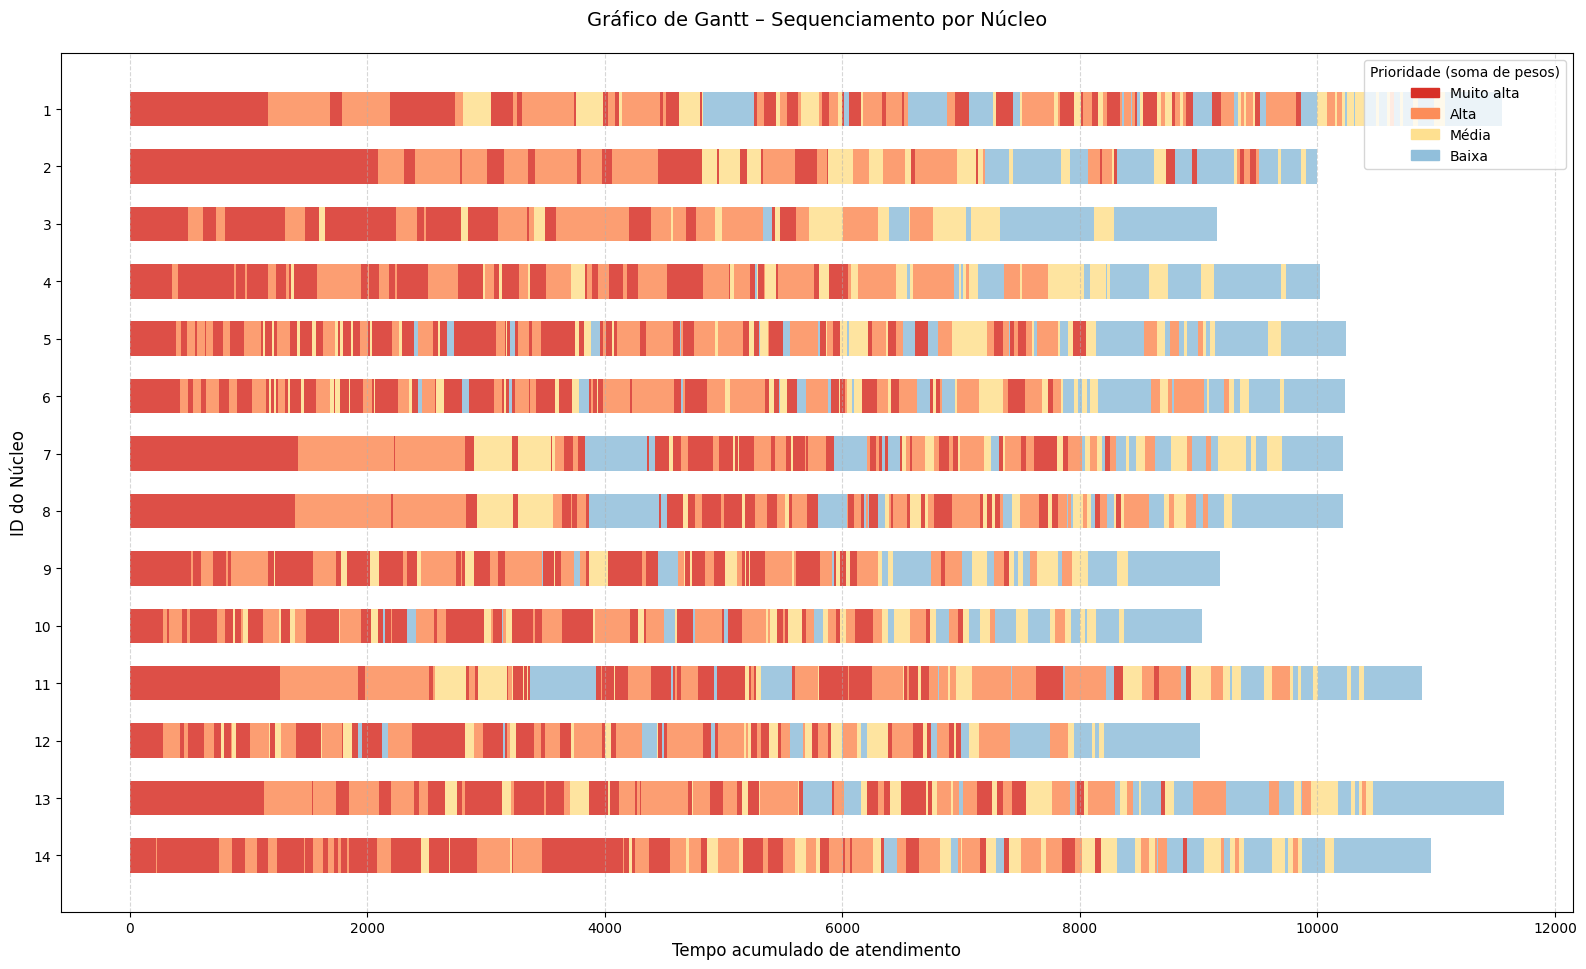

In [27]:
# ------------------ GRÁFICO DE GANTT OTIMIZADO ------------------ #
print("\n# ------------------ GERANDO GRÁFICO DE GANTT ------------------ #")

df_plot = df_heur.copy()

df_plot["Início (S)"] = pd.to_numeric(df_plot["Início (S)"], errors="coerce")
df_plot["Conclusão (C)"] = pd.to_numeric(df_plot["Conclusão (C)"], errors="coerce")
df_plot["Núcleo"] = pd.to_numeric(df_plot["Núcleo"], errors="coerce")
df_plot["Peso (prioridade)"] = pd.to_numeric(df_plot["Peso (prioridade)"], errors="coerce")

df_plot = df_plot.dropna(subset=["Início (S)", "Conclusão (C)", "Núcleo", "Peso (prioridade)"]).copy()
df_plot["Núcleo"] = df_plot["Núcleo"].astype(int)
df_plot["Duração"] = df_plot["Conclusão (C)"] - df_plot["Início (S)"]
df_plot = df_plot[df_plot["Duração"] > 0].copy()

def classe_peso(wj):
    if wj >= 7:
        return "Muito alta"
    elif wj >= 5:
        return "Alta"
    elif wj >= 3:
        return "Média"
    else:
        return "Baixa"

df_plot["Classe_prioridade"] = df_plot["Peso (prioridade)"].apply(classe_peso)

cores = {
    "Muito alta": "#d73027",
    "Alta": "#fc8d59",
    "Média": "#fee090",
    "Baixa": "#91bfdb",
}

nucleos = sorted(df_plot["Núcleo"].unique())
fig_height = max(7, len(nucleos) * 0.7)
fig, ax = plt.subplots(figsize=(16, fig_height))

altura = 6
espacamento = 10
posicoes = {n: i * espacamento for i, n in enumerate(nucleos)}

for nucleo in nucleos:
    y0 = posicoes[nucleo]
    dados_nucleo = df_plot[df_plot["Núcleo"] == nucleo]

    for classe, cor in cores.items():
        dados_classe = dados_nucleo[dados_nucleo["Classe_prioridade"] == classe]
        intervalos = list(zip(dados_classe["Início (S)"], dados_classe["Duração"]))

        if intervalos:
            ax.broken_barh(intervalos, (y0, altura), facecolors=cor, edgecolors="none", alpha=0.85)

ax.set_xlabel("Tempo acumulado de atendimento", fontsize=12)
ax.set_ylabel("ID do Núcleo", fontsize=12)
ax.set_title("Gráfico de Gantt – Sequenciamento por Núcleo", fontsize=14, pad=20)

ax.set_yticks([posicoes[n] + altura / 2 for n in nucleos])
ax.set_yticklabels(nucleos)
ax.invert_yaxis()
ax.grid(True, axis="x", linestyle="--", alpha=0.5)

ordem_classes = ["Muito alta", "Alta", "Média", "Baixa"]
legendas = [mpatches.Patch(color=cores[c], label=c) for c in ordem_classes]
ax.legend(handles=legendas, title="Prioridade (soma de pesos)", loc="upper right")

plt.tight_layout()
plt.show()

In [26]:
# EXPORTAR XLSX

df_heur.to_excel("resultado_heuristica_por_distrito_codigo-oficiais.xlsx")